In [60]:
import pyspark
import pandas as pd
from pyspark.sql.window import Window

from pyspark.sql import SparkSession, functions as F
from pyspark.sql.functions import countDistinct, col, lit, count, when, trim, row_number, concat, round, format_number, format_string
from pyspark.sql.types import DecimalType, IntegerType
spark = SparkSession.builder.appName('Week 3').getOrCreate()

In [61]:
df_cdl = spark.read.option('header', 'true').csv("week3-ds-cdl.tsv", sep='\t')
print(df_cdl.distinct().count())
print(df_cdl.count())
# df_cdl.columns

print(df_cdl.select('Hashed Ubermedia Id').distinct().count())

# cdl = df_cdl.select('Hashed Ubermedia Id').distinct()
# cdl.show()

7520
7520
7412


In [62]:
dadmin = df_cdl.select('Common Daytime Admin').distinct().count()
print(dadmin)

495


In [63]:
dadmin_count = df_cdl.groupby('Common Daytime Admin').count()
dadmin_count.show()
print(dadmin_count.count())


+--------------------+-----+
|Common Daytime Admin|count|
+--------------------+-----+
|   Williamson County|   96|
|     McLennan County|    7|
|     Canadian County|    1|
|Lewis and Clark C...|    1|
|     Muskegon County|    1|
|     Woodward County|    1|
|      Webster County|    1|
|   Cumberland County|    2|
|       DuPage County|    1|
|      El Paso County|   33|
|       Sutter County|   30|
|       Dakota County|    3|
|    Robertson County|    1|
|         Will County|    3|
|     Beltrami County|    1|
|     Lycoming County|    1|
|       Benton County|    8|
|    Wyandotte County|    1|
|       Colusa County|    3|
|   Bernalillo County|   15|
+--------------------+-----+
only showing top 20 rows
495


In [64]:
df_cel = spark.read.option('header', 'true').csv("week3-ds-cel.tsv", sep='\t')
# df_cel.show()
df_cel.count()

7324

In [65]:
eadmin = df_cel.select('Common Evening Admin').distinct().count()
print(eadmin)

499


In [66]:
eadmin_count = df_cel.groupby('Common Evening Admin').count()
eadmin_count.show()
print(eadmin_count.count())


+--------------------+-----+
|Common Evening Admin|count|
+--------------------+-----+
|   Williamson County|   95|
|     McLennan County|    7|
|Lewis and Clark C...|    1|
|     Woodward County|    1|
|       DuPage County|    2|
|      El Paso County|   34|
|       Sutter County|   34|
|       Dakota County|    3|
|    Robertson County|    1|
|         Will County|    4|
|     Beltrami County|    1|
|     Lycoming County|    1|
|       Benton County|    7|
|       Colusa County|    2|
|   Bernalillo County|   14|
|         Knox County|    2|
|      Osceola County|    3|
|        Starr County|    2|
|      Ballard County|    1|
|       Denver County|    1|
+--------------------+-----+
only showing top 20 rows
499


HOW MANY PEOPLE ORIGINATE FROM WHAT ADMIN LOCATIONS:

In [67]:
df_cel_renamed = df_cel.select('Hashed Ubermedia ID', df_cel['Common Evening Admin'].alias('admin location'))
df_cdl_renamed = df_cdl.select('Hashed Ubermedia ID', df_cdl['Common Daytime Admin'].alias('admin location'))

df_combined = df_cel_renamed.union(df_cdl_renamed)

id_counts = df_combined.groupBy('admin location').count()
print(id_counts.count())
id_counts.show()

535
+--------------------+-----+
|      admin location|count|
+--------------------+-----+
|   Williamson County|  191|
|     McLennan County|   14|
|Lewis and Clark C...|    2|
|     Woodward County|    2|
|       DuPage County|    3|
|      El Paso County|   67|
|       Sutter County|   64|
|       Dakota County|    6|
|    Robertson County|    2|
|         Will County|    7|
|     Beltrami County|    2|
|     Lycoming County|    2|
|       Benton County|   15|
|       Colusa County|    5|
|   Bernalillo County|   29|
|         Knox County|    4|
|      Osceola County|    6|
|        Starr County|    4|
|      Ballard County|    1|
|       Denver County|    3|
+--------------------+-----+
only showing top 20 rows


MEDIAN DISTANCE TRAVELLED FOR EACH POLYGON ID

In [68]:
df_cel_renamed = df_cel.select('Polygon ID', df_cel['Common Evening Distance Mi'].alias('distance'))
df_cdl_renamed = df_cdl.select('Polygon ID', df_cdl['Common Daytime Distance Mi'].alias('distance'))

df_combined = df_cel_renamed.union(df_cdl_renamed)

# df_combined.orderBy('Polygon ID').show(truncate=False)
df_combined.groupBy("Polygon ID").agg(F.median('distance')).show(truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------+------------------+
|Polygon ID                                                                                                                   |median(distance)  |
+-----------------------------------------------------------------------------------------------------------------------------+------------------+
|Blue Nile Blue Nile Jewelry - Houston Galleria, Houston, TX|11050619                                                         |19.63394          |
|Blue Nile Blue Nile Jewelry - Garden State Plaza, Paramus, NJ|11050629                                                       |7.038697          |
|Blue Nile Washington Square, Portland, OR|9695391                                                                            |9.514476          |
|Blue Nile The Mall at Rockingham Park, Salem, NH|9695393                                                             

AVG DISTANCE TRAVELLED FOR EACH POLYGON ID

In [69]:
df_cel_renamed = df_cel.select('Polygon ID', df_cel['Common Evening Distance Mi'].alias('distance'))
df_cdl_renamed = df_cdl.select('Polygon ID', df_cdl['Common Daytime Distance Mi'].alias('distance'))

df_combined = df_cel_renamed.union(df_cdl_renamed)

# df_combined.orderBy('Polygon ID').show(truncate=False)
df_combined.groupBy("Polygon ID").agg(F.mean('distance')).show(truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------+------------------+
|Polygon ID                                                                                                                   |avg(distance)     |
+-----------------------------------------------------------------------------------------------------------------------------+------------------+
|Blue Nile Blue Nile Jewelry - Houston Galleria, Houston, TX|11050619                                                         |189.72553584788787|
|Blue Nile Blue Nile Jewelry - Garden State Plaza, Paramus, NJ|11050629                                                       |53.65815913113605 |
|Blue Nile Washington Square, Portland, OR|9695391                                                                            |100.29100898470949|
|Blue Nile The Mall at Rockingham Park, Salem, NH|9695393                                                             

Finding the trade area

In [70]:
df_cel_renamed = df_cel.select('Polygon ID', df_cel['Common Evening Distance Mi'].alias('Distance Mi'))
df_cdl_renamed = df_cdl.select('Polygon ID', df_cdl['Common Daytime Distance Mi'].alias('Distance Mi'))

df_combined = df_cel_renamed.union(df_cdl_renamed)
df_combined = df_combined.withColumn("Distance Mi", col("Distance Mi").cast("double"))
# df_combined_dis = df_combined.withColumn("Distance Mi", col("Distance Mi").cast("double"))
df_combined_filtered = df_combined.filter(col("Distance Mi").isNotNull())

# trade_area = df_combined_filtered.groupBy("Polygon ID").agg(F.expr('percentile_approx(`Distance Mi`, 0.60)').alias('60%'))
# trade_area.show(truncate=False)

trade_area = df_combined_filtered.groupBy("Polygon ID").agg(F.expr('percentile_approx(`Distance Mi`, 0.70)').alias('70%'))
trade_area.show(truncate=False)

trade_area = df_combined_filtered.groupBy("Polygon ID").agg(F.expr('percentile_approx(`Distance Mi`, 0.80)').alias('80%'))
trade_area.show(truncate=False)


+-----------------------------------------------------------------------------------------------------------------------------+----------+
|Polygon ID                                                                                                                   |70%       |
+-----------------------------------------------------------------------------------------------------------------------------+----------+
|Blue Nile Blue Nile Jewelry - Houston Galleria, Houston, TX|11050619                                                         |106.850194|
|Blue Nile Blue Nile Jewelry - Garden State Plaza, Paramus, NJ|11050629                                                       |10.777921 |
|Blue Nile Washington Square, Portland, OR|9695391                                                                            |21.166168 |
|Blue Nile The Mall at Rockingham Park, Salem, NH|9695393                                                                     |14.332404 |
|Blue Nile Blue Nile Jewelr

================================================================================


Total Number of Visits for each Polygon

In [71]:
df_cdl_visits = df_cdl.withColumn("Visits", col("Visits").cast("int"))
df_cdl_visits = df_cdl_visits.groupBy("Polygon ID").agg(F.sum("Visits").alias("Total CDL Visits"))
df_cdl_visits.show(truncate=False)

df_cel_visits = df_cel.withColumn("Visits", col("Visits").cast("int"))
df_cel_visits = df_cel_visits.groupBy("Polygon ID").agg(F.sum("Visits").alias("Total CEL Visits"))
df_cel_visits.show(truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------+----------------+
|Polygon ID                                                                                                                   |Total CDL Visits|
+-----------------------------------------------------------------------------------------------------------------------------+----------------+
|Blue Nile Blue Nile Jewelry - Houston Galleria, Houston, TX|11050619                                                         |2420            |
|Blue Nile Blue Nile Jewelry - Garden State Plaza, Paramus, NJ|11050629                                                       |1219            |
|Blue Nile Washington Square, Portland, OR|9695391                                                                            |284             |
|Blue Nile The Mall at Rockingham Park, Salem, NH|9695393                                                                     |767

Total Number of Visitors

In [72]:
df_cdl_visitors = df_cdl.groupBy("Polygon ID").agg(F.count("*").alias("Total CDL Visitors"))
df_cdl_visitors.show(truncate=False)

df_cel_visitors = df_cel.groupBy("Polygon ID").agg(F.count("*").alias("Total CEL Visitors"))
df_cel_visitors.show(truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------+------------------+
|Polygon ID                                                                                                                   |Total CDL Visitors|
+-----------------------------------------------------------------------------------------------------------------------------+------------------+
|Blue Nile Blue Nile Jewelry - Houston Galleria, Houston, TX|11050619                                                         |1949              |
|Blue Nile Blue Nile Jewelry - Garden State Plaza, Paramus, NJ|11050629                                                       |729               |
|Blue Nile Washington Square, Portland, OR|9695391                                                                            |164               |
|Blue Nile The Mall at Rockingham Park, Salem, NH|9695393                                                             

Median Distance Traveled

In [73]:
df_cdl.groupBy("Polygon ID").agg(F.median('Common Daytime Distance Mi')).alias("Median distance traveled from CDL").show(truncate=False)
df_cel.groupBy("Polygon ID").agg(F.median('Common Evening Distance Mi')).alias("Median distance traveled from CEL").show(truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------+----------------------------------+
|Polygon ID                                                                                                                   |median(Common Daytime Distance Mi)|
+-----------------------------------------------------------------------------------------------------------------------------+----------------------------------+
|Blue Nile Blue Nile Jewelry - Houston Galleria, Houston, TX|11050619                                                         |19.554509                         |
|Blue Nile Blue Nile Jewelry - Garden State Plaza, Paramus, NJ|11050629                                                       |7.067451                          |
|Blue Nile Washington Square, Portland, OR|9695391                                                                            |9.5188055                         |
|Blue Nile The Mall at

Living Distance Calculations - Visit Count

In [74]:
df_cel = df_cel.withColumn("Distance Mi", F.expr("try_cast(`Common Evening Distance Mi` as double)"))
df_cel_within_1mi = df_cel.filter(col("Distance Mi") < 1)
df_cel_within_1mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Lives Within 1 Mi")).show(truncate=False)

df_cel_1_2mi = df_cel.filter((col("Distance Mi") >= 1) & (col("Distance Mi") < 2))
df_cel_1_2mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Lives between 1 and 2 Miles")).show(truncate=False)

df_cel_2_3mi = df_cel.filter((col("Distance Mi") >= 2) & (col("Distance Mi") < 2))
df_cel_2_3mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Lives between 2 and 3 Miles")).show(truncate=False)

df_cel_3_5mi = df_cel.filter((col("Distance Mi") >= 3) & (col("Distance Mi") < 5))
df_cel_3_5mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Lives between 3 and 5 Miles")).show(truncate=False)

df_cel_5_10mi = df_cel.filter((col("Distance Mi") >=5) & (col("Distance Mi") < 10))
df_cel_5_10mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Lives between 5 and 10 Miles")).show(truncate=False)

df_cel_10_25mi = df_cel.filter((col("Distance Mi") >=10) & (col("Distance Mi") < 25))
df_cel_10_25mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Lives between 10 and 25 Miles")).show(truncate=False)

df_cel_25_50mi = df_cel.filter((col("Distance Mi") >=25) & (col("Distance Mi") < 50))
df_cel_25_50mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Lives between 25 and 50 Miles")).show(truncate=False)

df_cel_50_100mi = df_cel.filter((col("Distance Mi") >=50) & (col("Distance Mi") < 100))
df_cel_50_100mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Lives between 50 and 100 Miles")).show(truncate=False)

df_cel_over_100mi = df_cel.filter((col("Distance Mi") >=100))
df_cel_over_100mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Lives > 100 Miles")).show(truncate=False)


+-----------------------------------------------------------------------------------------------------------------------------+-----------------+
|Polygon ID                                                                                                                   |Lives Within 1 Mi|
+-----------------------------------------------------------------------------------------------------------------------------+-----------------+
|Blue Nile Blue Nile Jewelry - Houston Galleria, Houston, TX|11050619                                                         |133.0            |
|Blue Nile Blue Nile Jewelry - Garden State Plaza, Paramus, NJ|11050629                                                       |214.0            |
|Blue Nile Washington Square, Portland, OR|9695391                                                                            |5.0              |
|Blue Nile The Mall at Rockingham Park, Salem, NH|9695393                                                                   

Work Calculations - Visit Count

In [75]:
df_cdl = df_cdl.withColumn("Distance Mi", F.expr("try_cast(`Common Daytime Distance Mi` as double)"))
df_cdl_within_1mi = df_cdl.filter(col("Distance Mi") < 1)
df_cdl_within_1mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Works Within 1 Mi")).show(truncate=False)

df_cdl_within_2mi = df_cdl.filter((col("Distance Mi") >= 1) & (col("Distance Mi") < 2))
df_cdl_within_2mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Works between 1 and 2 Miles")).show(truncate=False)

df_cdl_within_3mi = df_cdl.filter((col("Distance Mi") >= 2) & (col("Distance Mi") < 2))
df_cdl_within_3mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Works between 2 and 3 Miles")).show(truncate=False)

df_cdl_within_5mi = df_cdl.filter((col("Distance Mi") >= 3) & (col("Distance Mi") < 5))
df_cdl_within_5mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Works between 3 and 5 Miles")).show(truncate=False)

df_cdl_within_10mi = df_cdl.filter((col("Distance Mi") >=5) & (col("Distance Mi") < 10))
df_cdl_within_10mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Works between 5 and 10 Miles")).show(truncate=False)

df_cdl_within_25mi = df_cdl.filter((col("Distance Mi") >=10) & (col("Distance Mi") < 25))
df_cdl_within_25mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Works between 10 and 25 Miles")).show(truncate=False)

df_cdl_within_50mi = df_cdl.filter((col("Distance Mi") >=25) & (col("Distance Mi") < 50))
df_cdl_within_50mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Works between 25 and 50 Miles")).show(truncate=False)

df_cdl_within_100mi = df_cdl.filter((col("Distance Mi") >=50) & (col("Distance Mi") < 100))
df_cdl_within_100mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Works between 50 and 100 Miles")).show(truncate=False)

df_cdl_more_100mi = df_cdl.filter((col("Distance Mi") >=100))
df_cdl_more_100mi.groupBy("Polygon ID").agg(F.sum("Visits").alias("Works > 100 Miles")).show(truncate=False)





+-----------------------------------------------------------------------------------------------------------------------------+-----------------+
|Polygon ID                                                                                                                   |Works Within 1 Mi|
+-----------------------------------------------------------------------------------------------------------------------------+-----------------+
|Blue Nile Blue Nile Jewelry - Houston Galleria, Houston, TX|11050619                                                         |311.0            |
|Blue Nile Blue Nile Jewelry - Garden State Plaza, Paramus, NJ|11050629                                                       |278.0            |
|Blue Nile Washington Square, Portland, OR|9695391                                                                            |88.0             |
|Blue Nile The Mall at Rockingham Park, Salem, NH|9695393                                                                   

SUMMARY TABLE

In [76]:
# Helper to align schema
def align_columns(df):
    return df.select(
        "Polygon ID",
        "Bucket",
        "Type",
        F.when(col("Bucket").contains("Median"), col("Visitor Count"))  # Keep the value type for medians
          .otherwise(col("Visitor Count").cast("int"))  # Cast to int for others
          .alias("Visitor Count"),
        F.col("Visit Count").cast("int")
    )

# 1. Cast distance column
df_cel = df_cel.withColumn("Distance Mi", F.expr("try_cast(`Common Evening Distance Mi` as double)"))
df_cdl = df_cdl.withColumn("Distance Mi", F.expr("try_cast(`Common Daytime Distance Mi` as double)"))

# 2. Total Visits
df_cel_visits = df_cel.groupBy("Polygon ID") \
    .agg(F.sum("Visits").alias("Visit Count"))

df_cdl_visits = df_cdl.groupBy("Polygon ID") \
    .agg(F.sum("Visits").alias("Visit Count"))

# 3. Total Visitors
df_cel_visitors = df_cel.groupBy("Polygon ID") \
    .agg(count("*").alias("Visitor Count"))

df_cel_totals = df_cel_visits.join(df_cel_visitors, on="Polygon ID", how="outer")
df_cel_totals = df_cel_totals \
    .withColumn("Bucket", lit("Total CEL")) \
    .withColumn("Type", lit("CEL Distance")) 

df_cdl_visitors = df_cdl.groupBy("Polygon ID") \
    .agg(count("*").alias("Visitor Count"))

df_cdl_totals = df_cdl_visits.join(df_cdl_visitors, on="Polygon ID", how="outer")
df_cdl_totals = df_cdl_totals \
    .withColumn("Bucket", lit("Total CDL")) \
    .withColumn("Type", lit("CDL Distance")) 

# 4. Median Distance
df_cel_median = df_cel.groupBy("Polygon ID") \
    .agg(F.expr("percentile_approx(`Distance Mi`, 0.5)").cast("double").alias("Visitor Count")) \
    .withColumn("Visit Count", lit(None).cast("int")) \
    .withColumn("Bucket", lit("Median distance traveled from CEL")) \
    .withColumn("Type", lit("CEL Distance")) 

df_cdl_median = df_cdl.groupBy("Polygon ID") \
    .agg(F.expr("percentile_approx(`Distance Mi`, 0.5)").cast("double").alias("Visitor Count")) \
    .withColumn("Visit Count", lit(None).cast("int")) \
    .withColumn("Bucket", lit("Median distance traveled from CDL")) \
    .withColumn("Type", lit("CDL Distance")) 

# 5. Lives within (CEL)

# 1 mile
df_cel_1mi_visits = df_cel.filter(col("Distance Mi") < 1) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count")) 
df_cel_1mi_visitors = df_cel.filter(col("Distance Mi") < 1) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cel_1mi = df_cel_1mi_visits.join(df_cel_1mi_visitors, on="Polygon ID", how="outer")
df_cel_1mi = df_cel_1mi \
    .withColumn("Bucket", lit("Lives within 1 mi")) \
    .withColumn("Type", lit("CEL Distance"))
  
# 1 - 2
df_cel_1_2mi_visits = df_cel.filter((col("Distance Mi") >= 1) & (col("Distance Mi") < 2)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count")) 

df_cel_1_2mi_visitors = df_cel.filter((col("Distance Mi") >= 1) & (col("Distance Mi") < 2)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count")) 

df_cel_1_2mi = df_cel_1_2mi_visits.join(df_cel_1_2mi_visitors, on="Polygon ID", how="outer")
df_cel_1_2mi = df_cel_1_2mi \
    .withColumn("Bucket", lit("Lives between 1 and 2 mi")) \
    .withColumn("Type", lit("CEL Distance"))

# 2 - 3
df_cel_2_3mi_visits = df_cel.filter((col("Distance Mi") >= 2) & (col("Distance Mi") < 3)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))
   
df_cel_2_3mi_visitors = df_cel.filter((col("Distance Mi") >= 2) & (col("Distance Mi") < 3)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))
    
df_cel_2_3mi = df_cel_2_3mi_visits.join(df_cel_2_3mi_visitors, on="Polygon ID", how="outer")
df_cel_2_3mi = df_cel_2_3mi \
    .withColumn("Bucket", lit("Lives between 2 and 3 mi")) \
    .withColumn("Type", lit("CEL Distance"))

# 3 - 5
df_cel_3_5mi_visits = df_cel.filter((col("Distance Mi") >= 3) & (col("Distance Mi") < 5)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cel_3_5mi_visitors = df_cel.filter((col("Distance Mi") >= 3) & (col("Distance Mi") < 5)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cel_3_5mi = df_cel_3_5mi_visits.join(df_cel_3_5mi_visitors, on="Polygon ID", how="outer")
df_cel_3_5mi = df_cel_3_5mi \
    .withColumn("Bucket", lit("Lives between 3 and 5 mi")) \
    .withColumn("Type", lit("CEL Distance"))

# 5 - 10
df_cel_5_10mi_visits = df_cel.filter((col("Distance Mi") >= 5) & (col("Distance Mi") < 10)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cel_5_10mi_visitors = df_cel.filter((col("Distance Mi") >= 5) & (col("Distance Mi") < 10)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cel_5_10mi = df_cel_5_10mi_visits.join(df_cel_5_10mi_visitors, on="Polygon ID", how="outer")
df_cel_5_10mi = df_cel_5_10mi \
    .withColumn("Bucket", lit("Lives between 5 and 10 mi")) \
    .withColumn("Type", lit("CEL Distance"))

# 10 - 25
df_cel_10_25mi_visits = df_cel.filter((col("Distance Mi") >= 10) & (col("Distance Mi") < 25)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cel_10_25mi_visitors = df_cel.filter((col("Distance Mi") >= 10) & (col("Distance Mi") < 25)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cel_10_25mi = df_cel_10_25mi_visits.join(df_cel_10_25mi_visitors, on="Polygon ID", how="outer")
df_cel_10_25mi = df_cel_10_25mi \
    .withColumn("Bucket", lit("Lives between 10 and 25 mi")) \
    .withColumn("Type", lit("CEL Distance"))

# 25 - 50
df_cel_25_50mi_visits = df_cel.filter((col("Distance Mi") >= 25) & (col("Distance Mi") < 50)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cel_25_50mi_visitors = df_cel.filter((col("Distance Mi") >= 25) & (col("Distance Mi") < 50)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cel_25_50mi = df_cel_25_50mi_visits.join(df_cel_25_50mi_visitors, on="Polygon ID", how="outer")
df_cel_25_50mi = df_cel_25_50mi \
    .withColumn("Bucket", lit("Lives between 25 and 50 mi")) \
    .withColumn("Type", lit("CEL Distance"))

# 50 - 100 
df_cel_50_100mi_visits = df_cel.filter((col("Distance Mi") >= 50) & (col("Distance Mi") < 100)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count")) 

df_cel_50_100mi_visitors = df_cel.filter((col("Distance Mi") >= 50) & (col("Distance Mi") < 100)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cel_50_100mi = df_cel_50_100mi_visits.join(df_cel_50_100mi_visitors, on="Polygon ID", how="outer")
df_cel_50_100mi = df_cel_50_100mi \
    .withColumn("Bucket", lit("Lives between 50 and 100 mi")) \
    .withColumn("Type", lit("CEL Distance"))

# 100
df_cel_100mi_visits = df_cel.filter((col("Distance Mi") >= 100)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cel_100mi_visitors = df_cel.filter((col("Distance Mi") >= 100)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cel_100mi = df_cel_100mi_visits.join(df_cel_100mi_visitors, on="Polygon ID", how="outer")
df_cel_100mi = df_cel_100mi \
    .withColumn("Bucket", lit("Lives >100 mi")) \
    .withColumn("Type", lit("CEL Distance"))

# Works Within (CDL)
# 1 mi
df_cdl_1mi_visits = df_cdl.filter(col("Distance Mi") < 1) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count")) 
df_cdl_1mi_visitors = df_cdl.filter(col("Distance Mi") < 1) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cdl_1mi = df_cdl_1mi_visits.join(df_cdl_1mi_visitors, on="Polygon ID", how="outer")
df_cdl_1mi = df_cdl_1mi \
    .withColumn("Bucket", lit("Works within 1 mi")) \
    .withColumn("Type", lit("CDL Distance"))
  
# 1 - 2
df_cdl_1_2mi_visits = df_cdl.filter((col("Distance Mi") >= 1) & (col("Distance Mi") < 2)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count")) 

df_cdl_1_2mi_visitors = df_cdl.filter((col("Distance Mi") >= 1) & (col("Distance Mi") < 2)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count")) 

df_cdl_1_2mi = df_cdl_1_2mi_visits.join(df_cdl_1_2mi_visitors, on="Polygon ID", how="outer")
df_cdl_1_2mi = df_cdl_1_2mi \
    .withColumn("Bucket", lit("Works between 1 and 2 mi")) \
    .withColumn("Type", lit("CDL Distance"))

# 2 - 3
df_cdl_2_3mi_visits = df_cdl.filter((col("Distance Mi") >= 2) & (col("Distance Mi") < 3)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))
   
df_cdl_2_3mi_visitors = df_cdl.filter((col("Distance Mi") >= 2) & (col("Distance Mi") < 3)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))
    
df_cdl_2_3mi = df_cdl_2_3mi_visits.join(df_cdl_2_3mi_visitors, on="Polygon ID", how="outer")
df_cdl_2_3mi = df_cdl_2_3mi \
    .withColumn("Bucket", lit("Works between 2 and 3 mi")) \
    .withColumn("Type", lit("CDL Distance"))

# 3 - 5
df_cdl_3_5mi_visits = df_cdl.filter((col("Distance Mi") >= 3) & (col("Distance Mi") < 5)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cdl_3_5mi_visitors = df_cdl.filter((col("Distance Mi") >= 3) & (col("Distance Mi") < 5)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cdl_3_5mi = df_cdl_3_5mi_visits.join(df_cdl_3_5mi_visitors, on="Polygon ID", how="outer")
df_cdl_3_5mi = df_cdl_3_5mi \
    .withColumn("Bucket", lit("Works between 3 and 5 mi")) \
    .withColumn("Type", lit("CDL Distance"))

# 5 - 10
df_cdl_5_10mi_visits = df_cdl.filter((col("Distance Mi") >= 5) & (col("Distance Mi") < 10)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cdl_5_10mi_visitors = df_cdl.filter((col("Distance Mi") >= 5) & (col("Distance Mi") < 10)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cdl_5_10mi = df_cdl_5_10mi_visits.join(df_cdl_5_10mi_visitors, on="Polygon ID", how="outer")
df_cdl_5_10mi = df_cdl_5_10mi \
    .withColumn("Bucket", lit("Works between 5 and 10 mi")) \
    .withColumn("Type", lit("CDL Distance"))

# 10 - 25
df_cdl_10_25mi_visits = df_cdl.filter((col("Distance Mi") >= 10) & (col("Distance Mi") < 25)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cdl_10_25mi_visitors = df_cdl.filter((col("Distance Mi") >= 10) & (col("Distance Mi") < 25)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cdl_10_25mi = df_cdl_10_25mi_visits.join(df_cdl_10_25mi_visitors, on="Polygon ID", how="outer")
df_cdl_10_25mi = df_cdl_10_25mi \
    .withColumn("Bucket", lit("Works between 10 and 25 mi")) \
    .withColumn("Type", lit("CDL Distance"))

# 25 - 50
df_cdl_25_50mi_visits = df_cdl.filter((col("Distance Mi") >= 25) & (col("Distance Mi") < 50)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cdl_25_50mi_visitors = df_cdl.filter((col("Distance Mi") >= 25) & (col("Distance Mi") < 50)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cdl_25_50mi = df_cdl_25_50mi_visits.join(df_cdl_25_50mi_visitors, on="Polygon ID", how="outer")
df_cdl_25_50mi = df_cdl_25_50mi \
    .withColumn("Bucket", lit("Works between 25 and 50 mi")) \
    .withColumn("Type", lit("CDL Distance"))

# 50 - 100 
df_cdl_50_100mi_visits = df_cdl.filter((col("Distance Mi") >= 50) & (col("Distance Mi") < 100)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count")) 

df_cdl_50_100mi_visitors = df_cdl.filter((col("Distance Mi") >= 50) & (col("Distance Mi") < 100)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cdl_50_100mi = df_cdl_50_100mi_visits.join(df_cdl_50_100mi_visitors, on="Polygon ID", how="outer")
df_cdl_50_100mi = df_cdl_50_100mi \
    .withColumn("Bucket", lit("Works between 50 and 100 mi")) \
    .withColumn("Type", lit("CDL Distance"))

# 100
df_cdl_100mi_visits = df_cdl.filter((col("Distance Mi") >= 100)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cdl_100mi_visitors = df_cdl.filter((col("Distance Mi") >= 100)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cdl_100mi = df_cdl_100mi_visits.join(df_cdl_100mi_visitors, on="Polygon ID", how="outer")
df_cdl_100mi = df_cdl_100mi \
    .withColumn("Bucket", lit("Works >100 mi")) \
    .withColumn("Type", lit("CDL Distance"))


# 7. Align all DataFrames
aligned_dfs = [
    align_columns(df_cel_totals),
    align_columns(df_cel_median),
    align_columns(df_cel_1mi),
    align_columns(df_cel_1_2mi),
    align_columns(df_cel_2_3mi),
    align_columns(df_cel_3_5mi),
    align_columns(df_cel_5_10mi),
    align_columns(df_cel_10_25mi),
    align_columns(df_cel_25_50mi),
    align_columns(df_cel_50_100mi),
    align_columns(df_cel_100mi),

    align_columns(df_cdl_totals),
    align_columns(df_cdl_median),
    align_columns(df_cdl_1mi),
    align_columns(df_cdl_1_2mi),
    align_columns(df_cdl_2_3mi),
    align_columns(df_cdl_3_5mi),
    align_columns(df_cdl_5_10mi),
    align_columns(df_cdl_10_25mi),
    align_columns(df_cdl_25_50mi),
    align_columns(df_cdl_50_100mi),
    align_columns(df_cdl_100mi),
]

# COUNTRY
df_cel_totals_clean = df_cel_totals.select(
    "Polygon ID",
    col("Visitor Count").alias("Total Visitor Count"),
    col("Visit Count").alias("Total Visit Count")
)

cel_country_counts = df_cel.groupBy("Polygon ID", "Common Evening Country").agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count")
)

cel_country_counts = cel_country_counts.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cel_country_counts = cel_country_counts.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
cel_country_counts = cel_country_counts.withColumn("rank", row_number().over(window_spec))
cel_country_counts = cel_country_counts.filter(col("rank") <= 20).drop("rank")

df_cdl_totals_clean = df_cdl_totals.select(
    "Polygon ID",
    col("Visitor Count").alias("Total Visitor Count"),
    col("Visit Count").alias("Total Visit Count")
)

cdl_country_counts = df_cdl.groupBy("Polygon ID", "Common Daytime Country").agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count")
)

cdl_country_counts = cdl_country_counts.join(
    df_cdl_totals_clean,
    on="Polygon ID",
    how="left"
)

cdl_country_counts = cdl_country_counts.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
cdl_country_counts = cdl_country_counts.withColumn("rank", row_number().over(window_spec))
cdl_country_counts = cdl_country_counts.filter(col("rank") <= 20).drop("rank")

# CENSUS 
cel_census_counts = df_cel.groupBy("Polygon ID", "Common Evening Census" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

cel_census_counts = cel_census_counts.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cel_census_counts = cel_census_counts.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
cel_census_counts = cel_census_counts.withColumn("rank", row_number().over(window_spec))
cel_census_counts = cel_census_counts.filter(col("rank") <= 20).drop("rank")

cdl_census_counts = df_cdl.groupBy("Polygon ID", "Common Daytime Census").agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count")
)

cdl_census_counts = cdl_census_counts.join(
    df_cdl_totals_clean,
    on="Polygon ID",
    how="left"
)

cdl_census_counts = cdl_census_counts.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)
window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
cdl_census_counts = cdl_census_counts.withColumn("rank", row_number().over(window_spec))
cdl_census_counts = cdl_census_counts.filter(col("rank") <= 20).drop("rank")

# MICRO
cel_micro_count = df_cel.groupBy("Polygon ID", "Common Evening Micro" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
cel_micro_count = cel_micro_count.withColumn("rank", row_number().over(window_spec))
cel_micro_count = cel_micro_count.filter(col("rank") <= 20).drop("rank")

cel_micro_count = cel_micro_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cel_micro_count = cel_micro_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

cdl_micro_count = df_cdl.groupBy("Polygon ID", "Common Daytime Micro" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
cdl_micro_count = cdl_micro_count.withColumn("rank", row_number().over(window_spec))
cdl_micro_count = cdl_micro_count.filter(col("rank") <= 20).drop("rank")

cdl_micro_count = cdl_micro_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cdl_micro_count = cdl_micro_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

#ADMIN
cel_admin_count = df_cel.groupBy("Polygon ID", "Common Evening Admin" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
cel_admin_count = cel_admin_count.withColumn("rank", row_number().over(window_spec))
cel_admin_count = cel_admin_count.filter(col("rank") <= 20).drop("rank")

cel_admin_count = cel_admin_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cel_admin_count = cel_admin_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

cdl_admin_count = df_cdl.groupBy("Polygon ID", "Common Daytime Admin" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
cdl_admin_count = cdl_admin_count.withColumn("rank", row_number().over(window_spec))
cdl_admin_count = cdl_admin_count.filter(col("rank") <= 20).drop("rank")

cdl_admin_count = cdl_admin_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cdl_admin_count = cdl_admin_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

#POSTAL 1
cel_postal1_count = df_cel.groupBy("Polygon ID", "Common Evening Postal1" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
cel_postal1_count = cel_postal1_count.withColumn("rank", row_number().over(window_spec))
cel_postal1_count = cel_postal1_count.filter(col("rank") <= 20).drop("rank")

cel_postal1_count = cel_postal1_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cel_postal1_count = cel_postal1_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

cdl_postal1_count = df_cdl.groupBy("Polygon ID", "Common Daytime Postal1" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
cdl_postal1_count = cdl_postal1_count.withColumn("rank", row_number().over(window_spec))
cdl_postal1_count = cdl_postal1_count.filter(col("rank") <= 20).drop("rank")

cdl_postal1_count = cdl_postal1_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cdl_postal1_count = cdl_postal1_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

#MUNICIPALITY
cel_municipality_count = df_cel.groupBy("Polygon ID", "Common Evening Municipality" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
cel_municipality_count = cel_municipality_count.withColumn("rank", row_number().over(window_spec))
cel_municipality_count = cel_municipality_count.filter(col("rank") <= 20).drop("rank")

cel_municipality_count = cel_municipality_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cel_municipality_count = cel_municipality_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

cdl_municipality_count = df_cdl.groupBy("Polygon ID", "Common Daytime Municipality" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
cdl_municipality_count = cdl_municipality_count.withColumn("rank", row_number().over(window_spec))
cdl_municipality_count = cdl_municipality_count.filter(col("rank") <= 20).drop("rank")

cdl_municipality_count = cdl_municipality_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cdl_municipality_count = cdl_municipality_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

#PROVINCE
cel_province_count = df_cel.groupBy("Polygon ID", "Common Evening Province" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
cel_province_count = cel_province_count.withColumn("rank", row_number().over(window_spec))
cel_province_count = cel_province_count.filter(col("rank") <= 20).drop("rank")

cel_province_count = cel_province_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cel_province_count = cel_province_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

cdl_province_count = df_cdl.groupBy("Polygon ID", "Common Daytime Province" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
cdl_province_count = cdl_province_count.withColumn("rank", row_number().over(window_spec))
cdl_province_count = cdl_province_count.filter(col("rank") <= 20).drop("rank")

cdl_province_count = cdl_province_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cdl_province_count = cdl_province_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

# 8. Combine all
from functools import reduce
df_cel_combined = reduce(lambda a, b: a.unionByName(b), aligned_dfs)

bucket_order = [
    "Total CEL",
    "Median distance traveled from CEL",
    "Lives within 1 mi",
    "Lives between 1 and 2 mi",
    "Lives between 2 and 3 mi",
    "Lives between 3 and 5 mi",
    "Lives between 5 and 10 mi",
    "Lives between 10 and 25 mi",
    "Lives between 25 and 50 mi",
    "Lives between 50 and 100 mi",
    "Lives >100 mi",
    "Total CDL",
    "Median distance traveled from CDL",
    "Works within 1 mi",
    "Works between 1 and 2 mi",
    "Works between 2 and 3 mi",
    "Works between 3 and 5 mi",
    "Works between 5 and 10 mi",
    "Works between 10 and 25 mi",
    "Works between 25 and 50 mi",
    "Works between 50 and 100 mi",
    "Works >100 mi"
]

total_df = df_cel_combined.filter(col("Bucket").isin("Total CEL", "Total CDL")) \
    .select(
        col("Polygon ID"),
        col("Type"),
        col("Visitor Count").alias("Total Visitor Count"),
        col("Visit Count").alias("Total Visit Count")
    )

df_cel_combined = df_cel_combined.join(
    total_df,
    on=["Polygon ID", "Type"],
    how="left"
)

# Calculate Percentages
df_cel_combined = df_cel_combined.withColumn(
    "Visitor Percentage", 
    F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", 
    F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

# Sort Columns
order_expr = when(col("Bucket") == bucket_order[0], 0)
for i, bucket in enumerate(bucket_order[1:], start=1):
    order_expr = order_expr.when(col("Bucket") == bucket, i)

df_cel_combined = df_cel_combined.withColumn("bucket_order", order_expr)

df_cel_combined = df_cel_combined.orderBy("Polygon ID", "bucket_order") \
    .drop("bucket_order", "Total Visitor Count", "Total Visit Count")

# Make null values empty
df_cel_combined = df_cel_combined.na.fill("")

# Get column titles and rename buckets
cel_country_counts_aligned = cel_country_counts.select(
    col("Polygon ID"),
    col("Common Evening Country").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CEL Country").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cdl_country_counts_aligned = cdl_country_counts.select(
    col("Polygon ID"),
    col("Common Daytime Country").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CDL Country").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cel_census_counts_aligned = cel_census_counts.select(
    col("Polygon ID"),
    col("Common Evening Census").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CEL Census").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cdl_census_counts_aligned = cdl_census_counts.select(
    col("Polygon ID"),
    col("Common Daytime Census").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CDL Census").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cel_micro_counts_aligned = cel_micro_count.select(
    col("Polygon ID"),
    col("Common Evening Micro").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CEL Micro").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cdl_micro_counts_aligned = cdl_micro_count.select(
    col("Polygon ID"),
    col("Common Daytime Micro").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CDL Micro").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cel_admin_counts_aligned = cel_admin_count.select(
    col("Polygon ID"),
    col("Common Evening Admin").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CEL Admin").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cdl_admin_counts_aligned = cdl_admin_count.select(
    col("Polygon ID"),
    col("Common Daytime Admin").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CDL Admin").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cel_postal1_counts_aligned = cel_postal1_count.select(
    col("Polygon ID"),
    col("Common Evening Postal1").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CEL Postal1").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cdl_postal1_counts_aligned = cdl_postal1_count.select(
    col("Polygon ID"),
    col("Common Daytime Postal1").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CDL Postal1").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cel_municipality_counts_aligned = cel_municipality_count.select(
    col("Polygon ID"),
    col("Common Evening Municipality").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CEL Municipality").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cdl_municipality_counts_aligned = cdl_municipality_count.select(
    col("Polygon ID"),
    col("Common Daytime Municipality").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CDL Municipality").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cel_province_counts_aligned = cel_province_count.select(
    col("Polygon ID"),
    col("Common Evening Province").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CEL Province").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cdl_province_counts_aligned = cdl_province_count.select(
    col("Polygon ID"),
    col("Common Daytime Province").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CDL Province").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

# Combine all data - cel with cdl then all combined dfs
df_country_counts_combined = cel_country_counts_aligned.unionByName(cdl_country_counts_aligned)
df_census_counts_combined = cel_census_counts_aligned.unionByName(cdl_census_counts_aligned)
df_micro_counts_combined = cel_micro_counts_aligned.unionByName(cdl_micro_counts_aligned)
df_admin_counts_combined = cel_admin_counts_aligned.unionByName(cdl_micro_counts_aligned)
df_postal1_counts_combined = cel_postal1_counts_aligned.unionByName(cdl_postal1_counts_aligned)
df_municipality_counts_combined = cel_municipality_counts_aligned.unionByName(cdl_municipality_counts_aligned)
df_province_counts_combined = cel_province_counts_aligned.unionByName(cdl_province_counts_aligned)

df_cel_combined = (
    df_cel_combined
    .unionByName(df_country_counts_combined)
    .unionByName(df_census_counts_combined)
    .unionByName(df_micro_counts_combined)
    .unionByName(df_admin_counts_combined)
    .unionByName(df_postal1_counts_combined)
    .unionByName(df_municipality_counts_combined)
    .unionByName(df_province_counts_combined)
)

# Rounding percentages
df_cel_combined = df_cel_combined.withColumn(
    "Visitor Count",
    when(
        col("Bucket").isin("Median distance traveled from CEL", "Median distance traveled from CDL"),
        col("Visitor Count")  # keep decimal
    ).otherwise(round(col("Visitor Count")).cast(IntegerType()))
)

# Drop columns only if they exist
columns_to_drop = ["bucket_order", "Total Visitor Count", "Total Visit Count"]
existing_cols = [col for col in columns_to_drop if col in df_cel_combined.columns]

df_cel_combined = df_cel_combined.drop(*existing_cols)

final_columns = [
    "Polygon ID",        
    "Bucket",
    "Type",
    "Visitor Count",
    "Visitor Percentage",
    "Visit Count",
    "Visit Percentage"
]

# Sort only by columns that exist
sort_cols = [col for col in ["Polygon ID", "bucket_order"] if col in df_cel_combined.columns]
df_cel_combined = df_cel_combined.orderBy(*sort_cols)

# More rounding + types
df_cel_combined = df_cel_combined.withColumn(
    "Visitor Count",
    when(
        col("Bucket").isin("Median distance traveled from CEL", "Median distance traveled from CDL"),
        col("Visitor Count")  # keep decimal for medians
    ).otherwise(round(col("Visitor Count")).cast(IntegerType()))
).withColumn(
    "Visit Count",
    round(col("Visit Count")).cast(IntegerType())
)


df_cel_combined.select(final_columns) \
    .coalesce(1) \
    .write.mode("overwrite") \
    .option("header", True) \
    .csv("Summary2")

# Formatting percents
df_cel_combined.show(truncate=False) 
df_cel_combined = df_cel_combined.withColumn(
    "Visitor Percentage",
    concat(
        F.format_number(col("Visitor Percentage"), 2),
        lit("%")
    )
)

#####
df_cel_combined = df_cel_combined.withColumn(
    "Visitor Count",
    when(
        col("Bucket").isin("Median distance traveled from CEL", "Median distance traveled from CDL"),
        format_number(col("Visitor Count"), 4)  # keep 2 decimals for medians
    ).otherwise(
        col("Visitor Count").cast("int").cast("string")  # convert to string for clean output like '31'
    )
) ##

df_cel_combined = df_cel_combined.withColumn(
    "Visit Percentage",
    concat(
        F.format_number(col("Visit Percentage"), 2),
        lit("%")
    )
)

#
df_cel_combined = df_cel_combined.withColumn(
    "Visitor Percentage",
    when(
        col("Bucket").isin("Median distance traveled from CEL", "Median distance traveled from CDL", "Total CEL", "Total CDL"),
        lit("")  # remove percent value
    ).otherwise(col("Visitor Percentage"))
)

df_cel_combined = df_cel_combined.withColumn(
    "Visitor Percentage",
    when(
        col("Bucket").isin("Total CEL", "Total CDL"),
        lit("")  # remove percent value
    ).otherwise(col("Visitor Percentage"))
)

df_cel_combined.select(final_columns) \
    .coalesce(1) \
    .write.mode("overwrite") \
    .option("header", True) \
    .csv("Summary2")
df_cel_combined.show(truncate=False)

25/07/29 13:37:57 WARN DAGScheduler: Broadcasting large task binary with size 1173.8 KiB
25/07/29 13:37:57 WARN DAGScheduler: Broadcasting large task binary with size 1191.7 KiB
25/07/29 13:37:58 WARN DAGScheduler: Broadcasting large task binary with size 1288.4 KiB
25/07/29 13:37:58 WARN DAGScheduler: Broadcasting large task binary with size 1288.7 KiB
25/07/29 13:37:58 WARN DAGScheduler: Broadcasting large task binary with size 1499.3 KiB
25/07/29 13:38:00 WARN DAGScheduler: Broadcasting large task binary with size 1173.8 KiB
25/07/29 13:38:00 WARN DAGScheduler: Broadcasting large task binary with size 1191.7 KiB
25/07/29 13:38:01 WARN DAGScheduler: Broadcasting large task binary with size 1288.6 KiB


+-------------------------------------------------------------------+--------------------+---------------------+-------------+-----------+------------------+----------------+
|Polygon ID                                                         |Type                |Bucket               |Visitor Count|Visit Count|Visitor Percentage|Visit Percentage|
+-------------------------------------------------------------------+--------------------+---------------------+-------------+-----------+------------------+----------------+
|Blue Nile Blue Nile Jewelry - Domain Northside, Austin, TX|11050622|CEL Distance        |Total CEL            |392.0        |1147       |100.0             |100.0           |
|Blue Nile Blue Nile Jewelry - Domain Northside, Austin, TX|11050622|Top CDL Province    |TX                   |374.0        |1116       |95.41             |97.3            |
|Blue Nile Blue Nile Jewelry - Domain Northside, Austin, TX|11050622|Top CEL Municipality|Austin, TX           |291.0        

25/07/29 13:38:03 WARN DAGScheduler: Broadcasting large task binary with size 1173.8 KiB
25/07/29 13:38:03 WARN DAGScheduler: Broadcasting large task binary with size 1191.7 KiB
25/07/29 13:38:04 WARN DAGScheduler: Broadcasting large task binary with size 1288.4 KiB
25/07/29 13:38:04 WARN DAGScheduler: Broadcasting large task binary with size 1288.7 KiB
25/07/29 13:38:04 WARN DAGScheduler: Broadcasting large task binary with size 1511.6 KiB
25/07/29 13:38:06 WARN DAGScheduler: Broadcasting large task binary with size 1173.8 KiB
25/07/29 13:38:07 WARN DAGScheduler: Broadcasting large task binary with size 1191.7 KiB
25/07/29 13:38:07 WARN DAGScheduler: Broadcasting large task binary with size 1289.0 KiB
25/07/29 13:38:07 WARN DAGScheduler: Broadcasting large task binary with size 1289.3 KiB


+-------------------------------------------------------------------+------------+---------------------------------+-------------+-----------+------------------+----------------+
|Polygon ID                                                         |Type        |Bucket                           |Visitor Count|Visit Count|Visitor Percentage|Visit Percentage|
+-------------------------------------------------------------------+------------+---------------------------------+-------------+-----------+------------------+----------------+
|Blue Nile Blue Nile Jewelry - Domain Northside, Austin, TX|11050622|CEL Distance|Total CEL                        |392          |1147       |                  |100.00%         |
|Blue Nile Blue Nile Jewelry - Domain Northside, Austin, TX|11050622|CEL Distance|Median distance traveled from CEL|10.7273      |NULL       |                  |NULL            |
|Blue Nile Blue Nile Jewelry - Domain Northside, Austin, TX|11050622|CEL Distance|Lives within 1 mi      

25/07/29 13:38:08 WARN DAGScheduler: Broadcasting large task binary with size 1291.3 KiB


In [77]:
# Helper to align schema
def align_columns(df):
    return df.select(
        "Polygon ID",
        "Bucket",
        "Type",
        F.when(col("Bucket").contains("Median"), col("Visitor Count"))  # Keep the value type for medians
          .otherwise(col("Visitor Count").cast("int"))  # Cast to int for others
          .alias("Visitor Count"),
        F.col("Visit Count").cast("int")
    )

# 1. Cast distance column
df_cel = df_cel.withColumn("Distance Mi", F.expr("try_cast(`Common Evening Distance Mi` as double)"))
df_cdl = df_cdl.withColumn("Distance Mi", F.expr("try_cast(`Common Daytime Distance Mi` as double)"))

# 2. Total Visits
df_cel_visits = df_cel.groupBy("Polygon ID") \
    .agg(F.sum("Visits").alias("Visit Count"))

df_cdl_visits = df_cdl.groupBy("Polygon ID") \
    .agg(F.sum("Visits").alias("Visit Count"))

# 3. Total Visitors
df_cel_visitors = df_cel.groupBy("Polygon ID") \
    .agg(count("*").alias("Visitor Count"))

df_cel_totals = df_cel_visits.join(df_cel_visitors, on="Polygon ID", how="outer")
df_cel_totals = df_cel_totals \
    .withColumn("Bucket", lit("Total CEL")) \
    .withColumn("Type", lit("CEL Distance")) 

df_cdl_visitors = df_cdl.groupBy("Polygon ID") \
    .agg(count("*").alias("Visitor Count"))

df_cdl_totals = df_cdl_visits.join(df_cdl_visitors, on="Polygon ID", how="outer")
df_cdl_totals = df_cdl_totals \
    .withColumn("Bucket", lit("Total CDL")) \
    .withColumn("Type", lit("CDL Distance")) 

# 4. Median Distance
df_cel_median = df_cel.groupBy("Polygon ID") \
    .agg(F.expr("percentile_approx(`Distance Mi`, 0.5)").cast("double").alias("Visitor Count")) \
    .withColumn("Visit Count", lit(None).cast("int")) \
    .withColumn("Bucket", lit("Median distance traveled from CEL")) \
    .withColumn("Type", lit("CEL Distance")) 

df_cdl_median = df_cdl.groupBy("Polygon ID") \
    .agg(F.expr("percentile_approx(`Distance Mi`, 0.5)").cast("double").alias("Visitor Count")) \
    .withColumn("Visit Count", lit(None).cast("int")) \
    .withColumn("Bucket", lit("Median distance traveled from CDL")) \
    .withColumn("Type", lit("CDL Distance")) 

# 5. Lives within (CEL)

# 1 mile
df_cel_1mi_visits = df_cel.filter(col("Distance Mi") < 1) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count")) 
df_cel_1mi_visitors = df_cel.filter(col("Distance Mi") < 1) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cel_1mi = df_cel_1mi_visits.join(df_cel_1mi_visitors, on="Polygon ID", how="outer")
df_cel_1mi = df_cel_1mi \
    .withColumn("Bucket", lit("Lives within 1 mi")) \
    .withColumn("Type", lit("CEL Distance"))
  
# 1 - 2
df_cel_1_2mi_visits = df_cel.filter((col("Distance Mi") >= 1) & (col("Distance Mi") < 2)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count")) 

df_cel_1_2mi_visitors = df_cel.filter((col("Distance Mi") >= 1) & (col("Distance Mi") < 2)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count")) 

df_cel_1_2mi = df_cel_1_2mi_visits.join(df_cel_1_2mi_visitors, on="Polygon ID", how="outer")
df_cel_1_2mi = df_cel_1_2mi \
    .withColumn("Bucket", lit("Lives between 1 and 2 mi")) \
    .withColumn("Type", lit("CEL Distance"))

# 2 - 3
df_cel_2_3mi_visits = df_cel.filter((col("Distance Mi") >= 2) & (col("Distance Mi") < 3)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))
   
df_cel_2_3mi_visitors = df_cel.filter((col("Distance Mi") >= 2) & (col("Distance Mi") < 3)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))
    
df_cel_2_3mi = df_cel_2_3mi_visits.join(df_cel_2_3mi_visitors, on="Polygon ID", how="outer")
df_cel_2_3mi = df_cel_2_3mi \
    .withColumn("Bucket", lit("Lives between 2 and 3 mi")) \
    .withColumn("Type", lit("CEL Distance"))

# 3 - 5
df_cel_3_5mi_visits = df_cel.filter((col("Distance Mi") >= 3) & (col("Distance Mi") < 5)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cel_3_5mi_visitors = df_cel.filter((col("Distance Mi") >= 3) & (col("Distance Mi") < 5)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cel_3_5mi = df_cel_3_5mi_visits.join(df_cel_3_5mi_visitors, on="Polygon ID", how="outer")
df_cel_3_5mi = df_cel_3_5mi \
    .withColumn("Bucket", lit("Lives between 3 and 5 mi")) \
    .withColumn("Type", lit("CEL Distance"))

# 5 - 10
df_cel_5_10mi_visits = df_cel.filter((col("Distance Mi") >= 5) & (col("Distance Mi") < 10)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cel_5_10mi_visitors = df_cel.filter((col("Distance Mi") >= 5) & (col("Distance Mi") < 10)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cel_5_10mi = df_cel_5_10mi_visits.join(df_cel_5_10mi_visitors, on="Polygon ID", how="outer")
df_cel_5_10mi = df_cel_5_10mi \
    .withColumn("Bucket", lit("Lives between 5 and 10 mi")) \
    .withColumn("Type", lit("CEL Distance"))

# 10 - 25
df_cel_10_25mi_visits = df_cel.filter((col("Distance Mi") >= 10) & (col("Distance Mi") < 25)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cel_10_25mi_visitors = df_cel.filter((col("Distance Mi") >= 10) & (col("Distance Mi") < 25)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cel_10_25mi = df_cel_10_25mi_visits.join(df_cel_10_25mi_visitors, on="Polygon ID", how="outer")
df_cel_10_25mi = df_cel_10_25mi \
    .withColumn("Bucket", lit("Lives between 10 and 25 mi")) \
    .withColumn("Type", lit("CEL Distance"))

# 25 - 50
df_cel_25_50mi_visits = df_cel.filter((col("Distance Mi") >= 25) & (col("Distance Mi") < 50)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cel_25_50mi_visitors = df_cel.filter((col("Distance Mi") >= 25) & (col("Distance Mi") < 50)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cel_25_50mi = df_cel_25_50mi_visits.join(df_cel_25_50mi_visitors, on="Polygon ID", how="outer")
df_cel_25_50mi = df_cel_25_50mi \
    .withColumn("Bucket", lit("Lives between 25 and 50 mi")) \
    .withColumn("Type", lit("CEL Distance"))

# 50 - 100 
df_cel_50_100mi_visits = df_cel.filter((col("Distance Mi") >= 50) & (col("Distance Mi") < 100)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count")) 

df_cel_50_100mi_visitors = df_cel.filter((col("Distance Mi") >= 50) & (col("Distance Mi") < 100)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cel_50_100mi = df_cel_50_100mi_visits.join(df_cel_50_100mi_visitors, on="Polygon ID", how="outer")
df_cel_50_100mi = df_cel_50_100mi \
    .withColumn("Bucket", lit("Lives between 50 and 100 mi")) \
    .withColumn("Type", lit("CEL Distance"))

# 100
df_cel_100mi_visits = df_cel.filter((col("Distance Mi") >= 100)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cel_100mi_visitors = df_cel.filter((col("Distance Mi") >= 100)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cel_100mi = df_cel_100mi_visits.join(df_cel_100mi_visitors, on="Polygon ID", how="outer")
df_cel_100mi = df_cel_100mi \
    .withColumn("Bucket", lit("Lives >100 mi")) \
    .withColumn("Type", lit("CEL Distance"))

# Works Within (CDL)
# 1 mi
df_cdl_1mi_visits = df_cdl.filter(col("Distance Mi") < 1) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count")) 
df_cdl_1mi_visitors = df_cdl.filter(col("Distance Mi") < 1) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cdl_1mi = df_cdl_1mi_visits.join(df_cdl_1mi_visitors, on="Polygon ID", how="outer")
df_cdl_1mi = df_cdl_1mi \
    .withColumn("Bucket", lit("Works within 1 mi")) \
    .withColumn("Type", lit("CDL Distance"))
  
# 1 - 2
df_cdl_1_2mi_visits = df_cdl.filter((col("Distance Mi") >= 1) & (col("Distance Mi") < 2)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count")) 

df_cdl_1_2mi_visitors = df_cdl.filter((col("Distance Mi") >= 1) & (col("Distance Mi") < 2)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count")) 

df_cdl_1_2mi = df_cdl_1_2mi_visits.join(df_cdl_1_2mi_visitors, on="Polygon ID", how="outer")
df_cdl_1_2mi = df_cdl_1_2mi \
    .withColumn("Bucket", lit("Works between 1 and 2 mi")) \
    .withColumn("Type", lit("CDL Distance"))

# 2 - 3
df_cdl_2_3mi_visits = df_cdl.filter((col("Distance Mi") >= 2) & (col("Distance Mi") < 3)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))
   
df_cdl_2_3mi_visitors = df_cdl.filter((col("Distance Mi") >= 2) & (col("Distance Mi") < 3)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))
    
df_cdl_2_3mi = df_cdl_2_3mi_visits.join(df_cdl_2_3mi_visitors, on="Polygon ID", how="outer")
df_cdl_2_3mi = df_cdl_2_3mi \
    .withColumn("Bucket", lit("Works between 2 and 3 mi")) \
    .withColumn("Type", lit("CDL Distance"))

# 3 - 5
df_cdl_3_5mi_visits = df_cdl.filter((col("Distance Mi") >= 3) & (col("Distance Mi") < 5)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cdl_3_5mi_visitors = df_cdl.filter((col("Distance Mi") >= 3) & (col("Distance Mi") < 5)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cdl_3_5mi = df_cdl_3_5mi_visits.join(df_cdl_3_5mi_visitors, on="Polygon ID", how="outer")
df_cdl_3_5mi = df_cdl_3_5mi \
    .withColumn("Bucket", lit("Works between 3 and 5 mi")) \
    .withColumn("Type", lit("CDL Distance"))

# 5 - 10
df_cdl_5_10mi_visits = df_cdl.filter((col("Distance Mi") >= 5) & (col("Distance Mi") < 10)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cdl_5_10mi_visitors = df_cdl.filter((col("Distance Mi") >= 5) & (col("Distance Mi") < 10)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cdl_5_10mi = df_cdl_5_10mi_visits.join(df_cdl_5_10mi_visitors, on="Polygon ID", how="outer")
df_cdl_5_10mi = df_cdl_5_10mi \
    .withColumn("Bucket", lit("Works between 5 and 10 mi")) \
    .withColumn("Type", lit("CDL Distance"))

# 10 - 25
df_cdl_10_25mi_visits = df_cdl.filter((col("Distance Mi") >= 10) & (col("Distance Mi") < 25)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cdl_10_25mi_visitors = df_cdl.filter((col("Distance Mi") >= 10) & (col("Distance Mi") < 25)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cdl_10_25mi = df_cdl_10_25mi_visits.join(df_cdl_10_25mi_visitors, on="Polygon ID", how="outer")
df_cdl_10_25mi = df_cdl_10_25mi \
    .withColumn("Bucket", lit("Works between 10 and 25 mi")) \
    .withColumn("Type", lit("CDL Distance"))

# 25 - 50
df_cdl_25_50mi_visits = df_cdl.filter((col("Distance Mi") >= 25) & (col("Distance Mi") < 50)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cdl_25_50mi_visitors = df_cdl.filter((col("Distance Mi") >= 25) & (col("Distance Mi") < 50)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cdl_25_50mi = df_cdl_25_50mi_visits.join(df_cdl_25_50mi_visitors, on="Polygon ID", how="outer")
df_cdl_25_50mi = df_cdl_25_50mi \
    .withColumn("Bucket", lit("Works between 25 and 50 mi")) \
    .withColumn("Type", lit("CDL Distance"))

# 50 - 100 
df_cdl_50_100mi_visits = df_cdl.filter((col("Distance Mi") >= 50) & (col("Distance Mi") < 100)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count")) 

df_cdl_50_100mi_visitors = df_cdl.filter((col("Distance Mi") >= 50) & (col("Distance Mi") < 100)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cdl_50_100mi = df_cdl_50_100mi_visits.join(df_cdl_50_100mi_visitors, on="Polygon ID", how="outer")
df_cdl_50_100mi = df_cdl_50_100mi \
    .withColumn("Bucket", lit("Works between 50 and 100 mi")) \
    .withColumn("Type", lit("CDL Distance"))

# 100
df_cdl_100mi_visits = df_cdl.filter((col("Distance Mi") >= 100)) \
    .groupBy("Polygon ID").agg(F.sum("Visits").alias("Visit Count"))

df_cdl_100mi_visitors = df_cdl.filter((col("Distance Mi") >= 100)) \
    .groupBy("Polygon ID").agg(count("*").alias("Visitor Count"))

df_cdl_100mi = df_cdl_100mi_visits.join(df_cdl_100mi_visitors, on="Polygon ID", how="outer")
df_cdl_100mi = df_cdl_100mi \
    .withColumn("Bucket", lit("Works >100 mi")) \
    .withColumn("Type", lit("CDL Distance"))


# 7. Align all DataFrames
aligned_dfs = [
    align_columns(df_cel_totals),
    align_columns(df_cel_median),
    align_columns(df_cel_1mi),
    align_columns(df_cel_1_2mi),
    align_columns(df_cel_2_3mi),
    align_columns(df_cel_3_5mi),
    align_columns(df_cel_5_10mi),
    align_columns(df_cel_10_25mi),
    align_columns(df_cel_25_50mi),
    align_columns(df_cel_50_100mi),
    align_columns(df_cel_100mi),

    align_columns(df_cdl_totals),
    align_columns(df_cdl_median),
    align_columns(df_cdl_1mi),
    align_columns(df_cdl_1_2mi),
    align_columns(df_cdl_2_3mi),
    align_columns(df_cdl_3_5mi),
    align_columns(df_cdl_5_10mi),
    align_columns(df_cdl_10_25mi),
    align_columns(df_cdl_25_50mi),
    align_columns(df_cdl_50_100mi),
    align_columns(df_cdl_100mi),
]

# COUNTRY
df_cel_totals_clean = df_cel_totals.select(
    "Polygon ID",
    col("Visitor Count").alias("Total Visitor Count"),
    col("Visit Count").alias("Total Visit Count")
)

cel_country_counts = df_cel.groupBy("Polygon ID", "Common Evening Country").agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count")
)

cel_country_counts = cel_country_counts.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cel_country_counts = cel_country_counts.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)


cel_country_counts = cel_country_counts.orderBy(F.col("Visitor Count").desc())


# window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
# cel_country_counts = cel_country_counts.withColumn("rank", row_number().over(window_spec))
# cel_country_counts = cel_country_counts.filter(col("rank") <= 20).drop("rank")

df_cdl_totals_clean = df_cdl_totals.select(
    "Polygon ID",
    col("Visitor Count").alias("Total Visitor Count"),
    col("Visit Count").alias("Total Visit Count")
)

cdl_country_counts = df_cdl.groupBy("Polygon ID", "Common Daytime Country").agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count")
)

cdl_country_counts = cdl_country_counts.join(
    df_cdl_totals_clean,
    on="Polygon ID",
    how="left"
)

cdl_country_counts = cdl_country_counts.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

cdl_country_counts = cdl_country_counts.orderBy(F.col("Visitor Count").desc())
# window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
# cdl_country_counts = cdl_country_counts.withColumn("rank", row_number().over(window_spec))
# cdl_country_counts = cdl_country_counts.filter(col("rank") <= 20).drop("rank")

# CENSUS 
cel_census_counts = df_cel.groupBy("Polygon ID", "Common Evening Census" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

cel_census_counts = cel_census_counts.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cel_census_counts = cel_census_counts.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

cel_census_counts = cel_census_counts.orderBy(F.col("Visitor Count").desc())


# window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
# cel_census_counts = cel_census_counts.withColumn("rank", row_number().over(window_spec))
# cel_census_counts = cel_census_counts.filter(col("rank") <= 20).drop("rank")

cdl_census_counts = df_cdl.groupBy("Polygon ID", "Common Daytime Census").agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count")
)

cdl_census_counts = cdl_census_counts.join(
    df_cdl_totals_clean,
    on="Polygon ID",
    how="left"
)

cdl_census_counts = cdl_census_counts.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

cdl_census_counts = cdl_census_counts.orderBy(F.col("Visitor Count").desc())


# window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
# cdl_census_counts = cdl_census_counts.withColumn("rank", row_number().over(window_spec))
# cdl_census_counts = cdl_census_counts.filter(col("rank") <= 20).drop("rank")

# MICRO
cel_micro_count = df_cel.groupBy("Polygon ID", "Common Evening Micro" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

cel_micro_count = cel_micro_count.orderBy(F.col("Visitor Count").desc())
# window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
# cel_micro_count = cel_micro_count.withColumn("rank", row_number().over(window_spec))
# cel_micro_count = cel_micro_count.filter(col("rank") <= 20).drop("rank")

cel_micro_count = cel_micro_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cel_micro_count = cel_micro_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)



cdl_micro_count = df_cdl.groupBy("Polygon ID", "Common Daytime Micro" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

cel_micro_count = cel_micro_count.orderBy(F.col("Visitor Count").desc())

# window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
# cdl_micro_count = cdl_micro_count.withColumn("rank", row_number().over(window_spec))
# cdl_micro_count = cdl_micro_count.filter(col("rank") <= 20).drop("rank")

cdl_micro_count = cdl_micro_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cdl_micro_count = cdl_micro_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

#ADMIN
cel_admin_count = df_cel.groupBy("Polygon ID", "Common Evening Admin" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

cel_admin_count = cel_admin_count.orderBy(F.col("Visitor Count").desc())

# window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
# cel_admin_count = cel_admin_count.withColumn("rank", row_number().over(window_spec))
# cel_admin_count = cel_admin_count.filter(col("rank") <= 20).drop("rank")

cel_admin_count = cel_admin_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cel_admin_count = cel_admin_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

cdl_admin_count = df_cdl.groupBy("Polygon ID", "Common Daytime Admin" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

cdl_admin_count = cdl_admin_count.orderBy(F.col("Visitor Count").desc())


# window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
# cdl_admin_count = cdl_admin_count.withColumn("rank", row_number().over(window_spec))
# cdl_admin_count = cdl_admin_count.filter(col("rank") <= 20).drop("rank")

cdl_admin_count = cdl_admin_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cdl_admin_count = cdl_admin_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

#POSTAL 1
cel_postal1_count = df_cel.groupBy("Polygon ID", "Common Evening Postal1" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

cel_postal1_count = cel_postal1_count.orderBy(F.col("Visitor Count").desc())

# window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
# cel_postal1_count = cel_postal1_count.withColumn("rank", row_number().over(window_spec))
# cel_postal1_count = cel_postal1_count.filter(col("rank") <= 20).drop("rank")

cel_postal1_count = cel_postal1_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cel_postal1_count = cel_postal1_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

cdl_postal1_count = df_cdl.groupBy("Polygon ID", "Common Daytime Postal1" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

cdl_postal1_count = cdl_postal1_count.orderBy(F.col("Visitor Count").desc())
# window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
# cdl_postal1_count = cdl_postal1_count.withColumn("rank", row_number().over(window_spec))
# cdl_postal1_count = cdl_postal1_count.filter(col("rank") <= 20).drop("rank")

cdl_postal1_count = cdl_postal1_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cdl_postal1_count = cdl_postal1_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

#MUNICIPALITY
cel_municipality_count = df_cel.groupBy("Polygon ID", "Common Evening Municipality" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))
cel_municipality_count = cel_municipality_count.orderBy(F.col("Visitor Count").desc())

# window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
# cel_municipality_count = cel_municipality_count.withColumn("rank", row_number().over(window_spec))
# cel_municipality_count = cel_municipality_count.filter(col("rank") <= 20).drop("rank")

cel_municipality_count = cel_municipality_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cel_municipality_count = cel_municipality_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

cdl_municipality_count = df_cdl.groupBy("Polygon ID", "Common Daytime Municipality" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

cdl_municipality_count = cdl_municipality_count.orderBy(F.col("Visitor Count").desc())

# window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
# cdl_municipality_count = cdl_municipality_count.withColumn("rank", row_number().over(window_spec))
# cdl_municipality_count = cdl_municipality_count.filter(col("rank") <= 20).drop("rank")

cdl_municipality_count = cdl_municipality_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cdl_municipality_count = cdl_municipality_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

#PROVINCE
cel_province_count = df_cel.groupBy("Polygon ID", "Common Evening Province" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

cel_province_count = cel_province_count.orderBy(F.col("Visitor Count").desc())


# window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
# cel_province_count = cel_province_count.withColumn("rank", row_number().over(window_spec))
# cel_province_count = cel_province_count.filter(col("rank") <= 20).drop("rank")

cel_province_count = cel_province_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cel_province_count = cel_province_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

cdl_province_count = df_cdl.groupBy("Polygon ID", "Common Daytime Province" ).agg(
    F.sum("Visits").alias("Visit Count"),
    F.count("*").alias("Visitor Count"))

cdl_province_count = cdl_province_count.orderBy(F.col("Visitor Count").desc())

# window_spec = Window.partitionBy("Polygon ID").orderBy(F.desc("Visitor Count"))
# cdl_province_count = cdl_province_count.withColumn("rank", row_number().over(window_spec))
# cdl_province_count = cdl_province_count.filter(col("rank") <= 20).drop("rank")

cdl_province_count = cdl_province_count.join(
    df_cel_totals_clean,
    on="Polygon ID",
    how="left"
)

cdl_province_count = cdl_province_count.withColumn(
    "Visitor Percentage", F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

# 8. Combine all
from functools import reduce
df_cel_combined = reduce(lambda a, b: a.unionByName(b), aligned_dfs)

bucket_order = [
    "Total CEL",
    "Median distance traveled from CEL",
    "Lives within 1 mi",
    "Lives between 1 and 2 mi",
    "Lives between 2 and 3 mi",
    "Lives between 3 and 5 mi",
    "Lives between 5 and 10 mi",
    "Lives between 10 and 25 mi",
    "Lives between 25 and 50 mi",
    "Lives between 50 and 100 mi",
    "Lives >100 mi",
    "Total CDL",
    "Median distance traveled from CDL",
    "Works within 1 mi",
    "Works between 1 and 2 mi",
    "Works between 2 and 3 mi",
    "Works between 3 and 5 mi",
    "Works between 5 and 10 mi",
    "Works between 10 and 25 mi",
    "Works between 25 and 50 mi",
    "Works between 50 and 100 mi",
    "Works >100 mi"
]

total_df = df_cel_combined.filter(col("Bucket").isin("Total CEL", "Total CDL")) \
    .select(
        col("Polygon ID"),
        col("Type"),
        col("Visitor Count").alias("Total Visitor Count"),
        col("Visit Count").alias("Total Visit Count")
    )

df_cel_combined = df_cel_combined.join(
    total_df,
    on=["Polygon ID", "Type"],
    how="left"
)

# Calculate Percentages
df_cel_combined = df_cel_combined.withColumn(
    "Visitor Percentage", 
    F.round((col("Visitor Count") / col("Total Visitor Count")) * 100, 2)
).withColumn(
    "Visit Percentage", 
    F.round((col("Visit Count") / col("Total Visit Count")) * 100, 2)
)

# Sort Columns
order_expr = when(col("Bucket") == bucket_order[0], 0)
for i, bucket in enumerate(bucket_order[1:], start=1):
    order_expr = order_expr.when(col("Bucket") == bucket, i)

df_cel_combined = df_cel_combined.withColumn("bucket_order", order_expr)

df_cel_combined = df_cel_combined.orderBy("Polygon ID", "bucket_order") \
    .drop("bucket_order", "Total Visitor Count", "Total Visit Count")

# Make null values empty
df_cel_combined = df_cel_combined.na.fill("")

# Get column titles and rename buckets
cel_country_counts_aligned = cel_country_counts.select(
    col("Polygon ID"),
    col("Common Evening Country").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CEL Country").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cdl_country_counts_aligned = cdl_country_counts.select(
    col("Polygon ID"),
    col("Common Daytime Country").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CDL Country").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cel_census_counts_aligned = cel_census_counts.select(
    col("Polygon ID"),
    col("Common Evening Census").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CEL Census").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cdl_census_counts_aligned = cdl_census_counts.select(
    col("Polygon ID"),
    col("Common Daytime Census").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CDL Census").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cel_micro_counts_aligned = cel_micro_count.select(
    col("Polygon ID"),
    col("Common Evening Micro").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CEL Micro").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cdl_micro_counts_aligned = cdl_micro_count.select(
    col("Polygon ID"),
    col("Common Daytime Micro").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CDL Micro").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cel_admin_counts_aligned = cel_admin_count.select(
    col("Polygon ID"),
    col("Common Evening Admin").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CEL Admin").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cdl_admin_counts_aligned = cdl_admin_count.select(
    col("Polygon ID"),
    col("Common Daytime Admin").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CDL Admin").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cel_postal1_counts_aligned = cel_postal1_count.select(
    col("Polygon ID"),
    col("Common Evening Postal1").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CEL Postal1").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cdl_postal1_counts_aligned = cdl_postal1_count.select(
    col("Polygon ID"),
    col("Common Daytime Postal1").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CDL Postal1").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cel_municipality_counts_aligned = cel_municipality_count.select(
    col("Polygon ID"),
    col("Common Evening Municipality").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CEL Municipality").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cdl_municipality_counts_aligned = cdl_municipality_count.select(
    col("Polygon ID"),
    col("Common Daytime Municipality").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CDL Municipality").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cel_province_counts_aligned = cel_province_count.select(
    col("Polygon ID"),
    col("Common Evening Province").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CEL Province").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

cdl_province_counts_aligned = cdl_province_count.select(
    col("Polygon ID"),
    col("Common Daytime Province").alias("Bucket"),  # ← this makes the country the bucket
    lit("Top CDL Province").alias("Type"),
    col("Visitor Count"),
    col("Visitor Percentage"),
    col("Visit Count"),
    col("Visit Percentage")
)

# Combine all data - cel with cdl then all combined dfs
df_country_counts_combined = cel_country_counts_aligned.unionByName(cdl_country_counts_aligned)
df_census_counts_combined = cel_census_counts_aligned.unionByName(cdl_census_counts_aligned)
df_micro_counts_combined = cel_micro_counts_aligned.unionByName(cdl_micro_counts_aligned)
df_admin_counts_combined = cel_admin_counts_aligned.unionByName(cdl_micro_counts_aligned)
df_postal1_counts_combined = cel_postal1_counts_aligned.unionByName(cdl_postal1_counts_aligned)
df_municipality_counts_combined = cel_municipality_counts_aligned.unionByName(cdl_municipality_counts_aligned)
df_province_counts_combined = cel_province_counts_aligned.unionByName(cdl_province_counts_aligned)

df_cel_combined = (
    df_cel_combined
    .unionByName(df_country_counts_combined)
    .unionByName(df_census_counts_combined)
    .unionByName(df_micro_counts_combined)
    .unionByName(df_admin_counts_combined)
    .unionByName(df_postal1_counts_combined)
    .unionByName(df_municipality_counts_combined)
    .unionByName(df_province_counts_combined)
)

# Rounding percentages
df_cel_combined = df_cel_combined.withColumn(
    "Visitor Count",
    when(
        col("Bucket").isin("Median distance traveled from CEL", "Median distance traveled from CDL"),
        col("Visitor Count")  # keep decimal
    ).otherwise(round(col("Visitor Count")).cast(IntegerType()))
)

# Drop columns only if they exist
columns_to_drop = ["bucket_order", "Total Visitor Count", "Total Visit Count"]
existing_cols = [col for col in columns_to_drop if col in df_cel_combined.columns]

df_cel_combined = df_cel_combined.drop(*existing_cols)

final_columns = [
    "Polygon ID",        
    "Bucket",
    "Type",
    "Visitor Count",
    "Visitor Percentage",
    "Visit Count",
    "Visit Percentage"
]

# Sort only by columns that exist
sort_cols = [col for col in ["Polygon ID", "bucket_order"] if col in df_cel_combined.columns]
df_cel_combined = df_cel_combined.orderBy(*sort_cols)

# More rounding + types
df_cel_combined = df_cel_combined.withColumn(
    "Visitor Count",
    when(
        col("Bucket").isin("Median distance traveled from CEL", "Median distance traveled from CDL"),
        col("Visitor Count")  # keep decimal for medians
    ).otherwise(round(col("Visitor Count")).cast(IntegerType()))
).withColumn(
    "Visit Count",
    round(col("Visit Count")).cast(IntegerType())
)


df_cel_combined.select(final_columns) \
    .coalesce(1) \
    .write.mode("overwrite") \
    .option("header", True) \
    .csv("Summary2")

# Formatting percents
df_cel_combined.show(truncate=False) 
df_cel_combined = df_cel_combined.withColumn(
    "Visitor Percentage",
    concat(
        F.format_number(col("Visitor Percentage"), 2),
        lit("%")
    )
)

#####
df_cel_combined = df_cel_combined.withColumn(
    "Visitor Count",
    when(
        col("Bucket").isin("Median distance traveled from CEL", "Median distance traveled from CDL"),
        format_number(col("Visitor Count"), 4)  # keep 2 decimals for medians
    ).otherwise(
        col("Visitor Count").cast("int").cast("string")  # convert to string for clean output like '31'
    )
) ##

df_cel_combined = df_cel_combined.withColumn(
    "Visit Percentage",
    concat(
        F.format_number(col("Visit Percentage"), 2),
        lit("%")
    )
)

#
df_cel_combined = df_cel_combined.withColumn(
    "Visitor Percentage",
    when(
        col("Bucket").isin("Median distance traveled from CEL", "Median distance traveled from CDL", "Total CEL", "Total CDL"),
        lit("")  # remove percent value
    ).otherwise(col("Visitor Percentage"))
)

df_cel_combined = df_cel_combined.withColumn(
    "Visitor Percentage",
    when(
        col("Bucket").isin("Total CEL", "Total CDL"),
        lit("")  # remove percent value
    ).otherwise(col("Visitor Percentage"))
)

df_cel_combined.select(final_columns) \
    .coalesce(1) \
    .write.mode("overwrite") \
    .option("header", True) \
    .csv("Summary3")
df_cel_combined.show(truncate=False)

25/07/29 13:38:11 WARN DAGScheduler: Broadcasting large task binary with size 1173.8 KiB
25/07/29 13:38:11 WARN DAGScheduler: Broadcasting large task binary with size 1191.7 KiB
25/07/29 13:38:11 WARN DAGScheduler: Broadcasting large task binary with size 1297.7 KiB
25/07/29 13:38:11 WARN DAGScheduler: Broadcasting large task binary with size 1298.3 KiB
25/07/29 13:38:11 WARN DAGScheduler: Broadcasting large task binary with size 1297.9 KiB
25/07/29 13:38:12 WARN DAGScheduler: Broadcasting large task binary with size 1399.4 KiB
25/07/29 13:38:14 WARN DAGScheduler: Broadcasting large task binary with size 1173.8 KiB
25/07/29 13:38:14 WARN DAGScheduler: Broadcasting large task binary with size 1191.7 KiB
25/07/29 13:38:14 WARN DAGScheduler: Broadcasting large task binary with size 1292.4 KiB


+-------------------------------------------------------------------+--------------------+-----------------------------------+-------------+-----------+------------------+----------------+
|Polygon ID                                                         |Type                |Bucket                             |Visitor Count|Visit Count|Visitor Percentage|Visit Percentage|
+-------------------------------------------------------------------+--------------------+-----------------------------------+-------------+-----------+------------------+----------------+
|Blue Nile Blue Nile Jewelry - Domain Northside, Austin, TX|11050622|Top CEL Country     |USA                                |389.0        |1144       |99.23             |99.74           |
|Blue Nile Blue Nile Jewelry - Domain Northside, Austin, TX|11050622|Top CDL Province    |OK                                 |1.0          |1          |0.26              |0.09            |
|Blue Nile Blue Nile Jewelry - Domain Northside, Austin

25/07/29 13:38:17 WARN DAGScheduler: Broadcasting large task binary with size 1173.8 KiB
25/07/29 13:38:17 WARN DAGScheduler: Broadcasting large task binary with size 1191.7 KiB
25/07/29 13:38:17 WARN DAGScheduler: Broadcasting large task binary with size 1297.7 KiB
25/07/29 13:38:18 WARN DAGScheduler: Broadcasting large task binary with size 1298.3 KiB
25/07/29 13:38:18 WARN DAGScheduler: Broadcasting large task binary with size 1297.9 KiB
25/07/29 13:38:18 WARN DAGScheduler: Broadcasting large task binary with size 1411.7 KiB
25/07/29 13:38:21 WARN DAGScheduler: Broadcasting large task binary with size 1173.8 KiB
25/07/29 13:38:21 WARN DAGScheduler: Broadcasting large task binary with size 1191.7 KiB
25/07/29 13:38:21 WARN DAGScheduler: Broadcasting large task binary with size 1297.7 KiB
25/07/29 13:38:22 WARN DAGScheduler: Broadcasting large task binary with size 1298.3 KiB
25/07/29 13:38:22 WARN DAGScheduler: Broadcasting large task binary with size 1297.9 KiB


+-------------------------------------------------------------------+------------+---------------------------------+-------------+-----------+------------------+----------------+
|Polygon ID                                                         |Type        |Bucket                           |Visitor Count|Visit Count|Visitor Percentage|Visit Percentage|
+-------------------------------------------------------------------+------------+---------------------------------+-------------+-----------+------------------+----------------+
|Blue Nile Blue Nile Jewelry - Domain Northside, Austin, TX|11050622|CEL Distance|Total CEL                        |392          |1147       |                  |100.00%         |
|Blue Nile Blue Nile Jewelry - Domain Northside, Austin, TX|11050622|CEL Distance|Median distance traveled from CEL|10.7273      |NULL       |                  |NULL            |
|Blue Nile Blue Nile Jewelry - Domain Northside, Austin, TX|11050622|CEL Distance|Lives within 1 mi      

25/07/29 13:38:22 WARN DAGScheduler: Broadcasting large task binary with size 1190.8 KiB


Trade Area plots

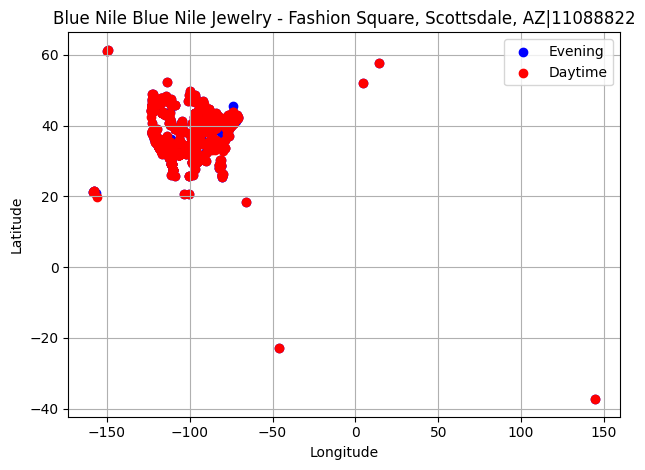

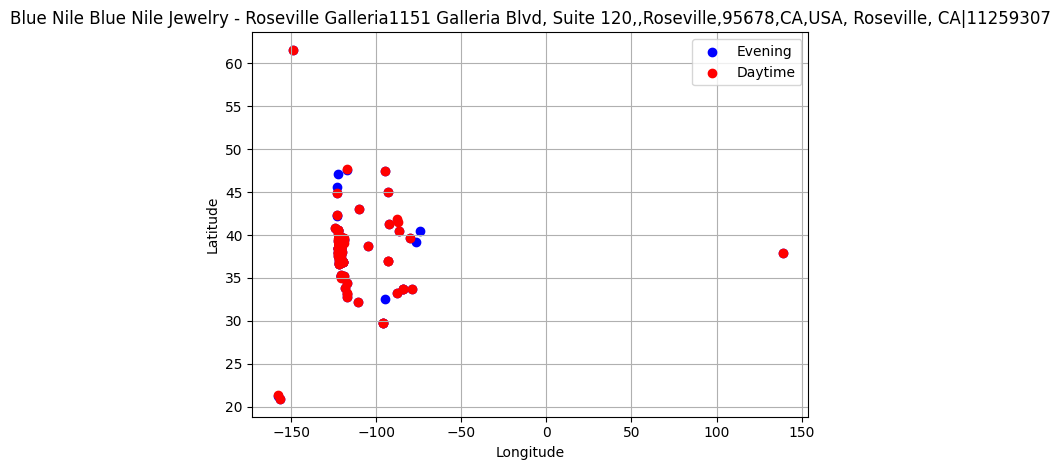

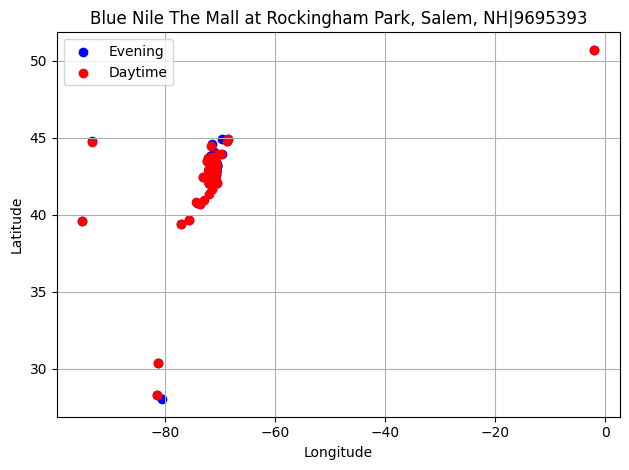

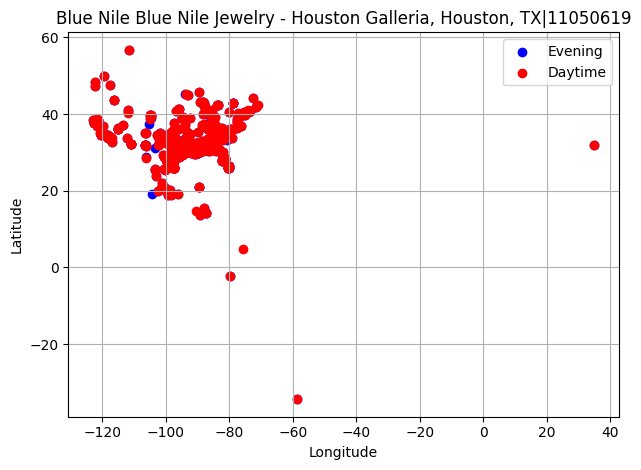

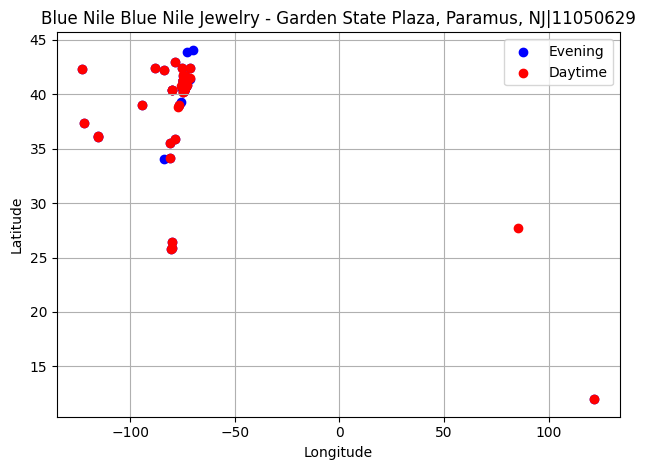

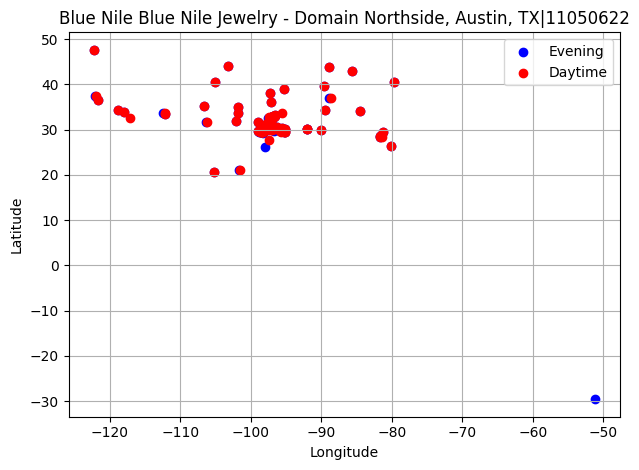

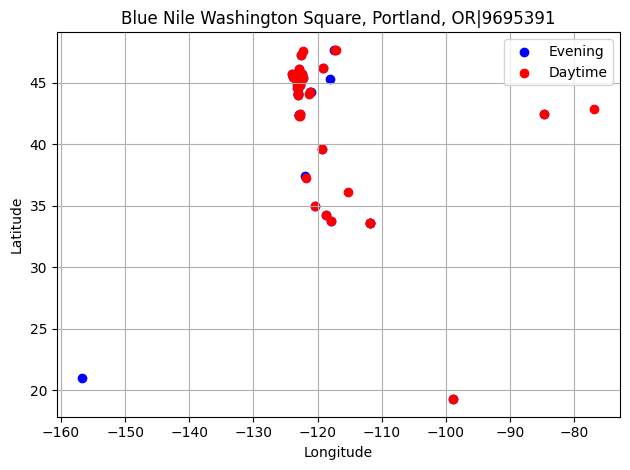

In [78]:
import matplotlib.pyplot as plt

df_cdl = pd.read_csv("week3-ds-cdl.tsv", sep="\t")
df_cel = pd.read_csv("week3-ds-cel.tsv", sep="\t")


for id in df_cel["Polygon Id"].unique():
    subset_cel = df_cel[df_cel["Polygon Id"] == id]
    
    x_cel = subset_cel["Common Evening Long"]
    y_cel = subset_cel["Common Evening Lat"]

    subset_cdl = df_cdl[df_cdl["Polygon Id"] == id]
    
    x_cdl = subset_cdl["Common Daytime Long"]
    y_cdl = subset_cdl["Common Daytime Lat"]
    plt.scatter(x_cel, y_cel, color="blue", label="Evening")
    plt.scatter(x_cdl, y_cdl, color="red", label="Daytime")
    
    plt.title(f"{id}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [79]:
spark.stop()